In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    VoiceTranscription,
)


config = CustomConfig('../configs/config.yaml')
loader = DataLoader(config, root='../')

In [3]:
from pathlib import Path

background_data= loader.get_slide_data('20260825_134215',#'20260609_112539',
                                       3,flatten=True)
output_dir = Path("./analysis_outputs")



In [7]:
analyzer = VoiceTranscription(
    output_folder=Path("analysis_outputs"),
    loader_root=loader.root,
    model_name="medium",
    language="en",   # or "pl", or None
    sentence_gap_threshold=0.6,
    audio_start_offset_sec=0.0
)

results = analyzer.analyze(
    background_data=background_data,
    per="slide"
)

#analyzer.save_results()
#

100%|█████████████████████████████████████| 1.42G/1.42G [11:32<00:00, 2.21MiB/s]
c:\Users\szymo\anaconda3\envs\pytracker-env\lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
100%|██████████| 2454/2454 [00:22<00:00, 107.70frames/s]


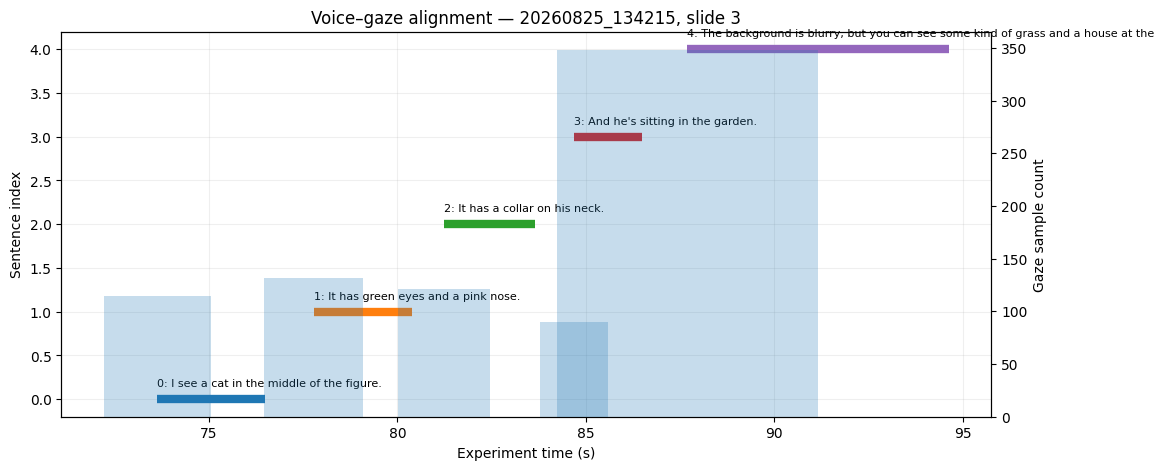

In [8]:
analyzer.plot_analysis_summary(set_name="20260825_134215",#"20260609_112539", 
                               slide_index=3)

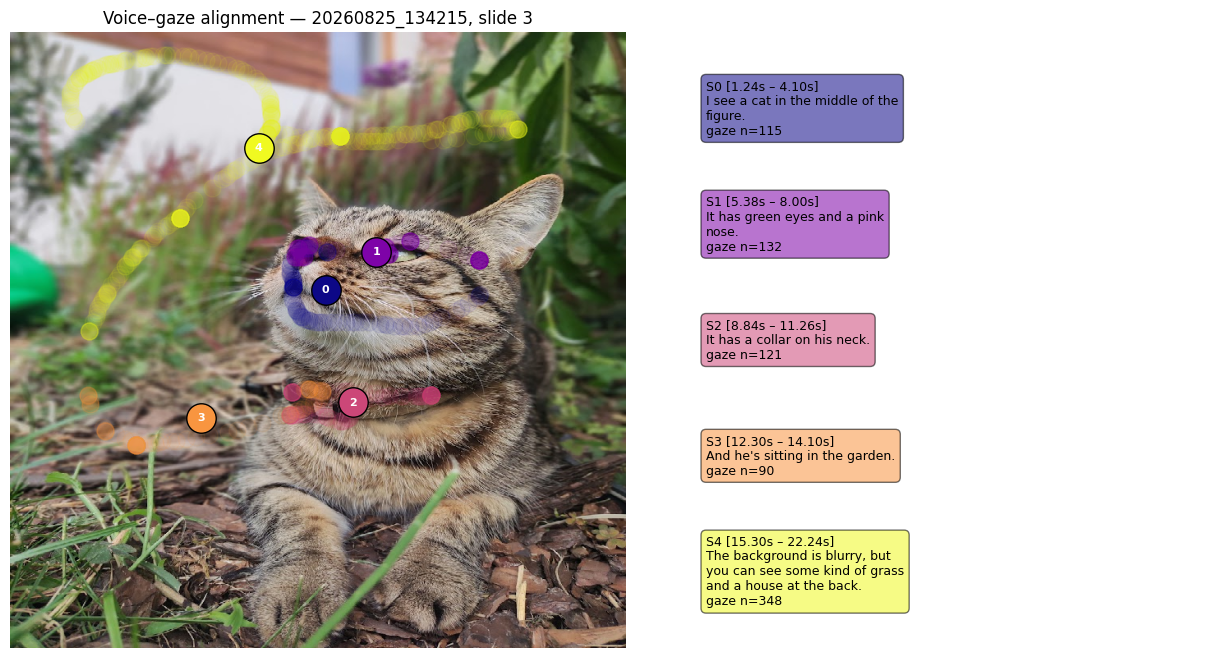

In [16]:
import textwrap

analyzer.plot_analysis(
    set_name="20260825_134215",#"20260609_112539",
    slide_index=3,
    alpha=0.07,
    point_size=150,
    colormap="plasma",
    show=True
)